# notebook to train with sparse data and test with dense data

# setup

In [1]:
import network
import torch
import torch.nn as nn
import torch.nn.functional as F

# Unlike object, with SimpleNamespace you can add and remove attributes.
from types import SimpleNamespace 
import numpy as np
import random

# set the network size, to feed into the 1-layer network class

In [9]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # chooses the device for computation

m = 50 # input dimension
n = 100 # measurement dimension

# Set seed
seed = 1
network.set_random_mode(True, seed)

init_parameters = SimpleNamespace()
init_parameters.m = m 
init_parameters.n = n 
init_parameters.seed = seed

# the measurement matrix: randomly initialized
init_parameters.W = torch.randn(n,m).to(device)

# /torch.sqrt(torch.tensor(n))

store_image = True

[Random Mode] Deterministic with seed 1


## save the parameters (input-to-measurement weight matrix W)

In [10]:
import pickle
import os

weight_folder = f'weights/m_{m}_n_{n}_s_{seed}'
os.makedirs(weight_folder, exist_ok=True)

param_path = f'{weight_folder}/init_params.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(init_parameters, f)

# create the network

In [11]:
enose_network = network.enose(init_parameters)

#prints network parameters
print("input dimension: " + str(enose_network.m))
print("measurement dimension: " + str(enose_network.n))
print("input-to-measurement matrix: " + str(enose_network.W))

# print network architecture
for name, param in enose_network.named_parameters():
    print(f"{name}: {param.shape}")

input dimension: 50
measurement dimension: 100
input-to-measurement matrix: tensor([[-1.5256, -0.7502, -0.6540,  ..., -0.6298, -0.9274,  0.5451],
        [ 0.0663, -0.4370,  0.7626,  ...,  1.1899,  0.8165, -0.9135],
        [ 1.3851, -0.8138, -0.9276,  ...,  0.6419,  0.4730, -0.4286],
        ...,
        [-1.1080, -1.3766, -0.6012,  ..., -1.4471,  0.1287, -0.2051],
        [ 0.6614,  0.6542,  0.0522,  ..., -1.2430,  0.1239,  0.5274],
        [ 1.7035,  0.5626,  0.3812,  ..., -1.3296, -1.2682, -1.5542]],
       device='mps:0')
fc1.weight: torch.Size([1, 100])
fc1.bias: torch.Size([1])


In [12]:
# parameters
num_data=10000
training_frac=0.8
is_balanced=True
threshold=0.1
x_hat = threshold
num_training = int(num_data*training_frac)
bounds = (0,1)
sparsity_index = 45

# creates sparse dataset*

In [13]:
# creates sparse dataset, only training set
zero_dataset = network.generate_dataset(m, n, device, num_data, training_frac, is_balanced, threshold, bounds, sparsity_index)
zero_train_conc = zero_dataset.train_conc
zero_train_labels = zero_dataset.train_labels

# create dense dataset with bi-directional option*

In [33]:
# creates dense training dataset, only test set
nonzero_dataset = network.generate_dataset(m, n, device, num_data, training_frac, is_balanced, threshold, bounds, None)
nonzero_test_conc = nonzero_dataset.test_conc
nonzero_test_labels = nonzero_dataset.test_labels
test_batch_size = 20


# initial accuracy
initial_accuracy = network.evaluate_random_batch(enose_network, nonzero_dataset, test_batch_size=20, threshold=0.1)
print(initial_accuracy)

0.699999988079071


# optimize the parameters using cross entropy, save the trained weights

In [34]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(enose_network.parameters(), lr = 0.001)
lr = 0.001
batch_size = 10
steps = 10000
loss_vec = torch.zeros(steps)

test_interval = 50 # to make sure that all the test data are used multiple times
print_interval = 1000 # how often to print the accuracies and loss in terminal
test_batch_size = 20 
accuracy_vec = torch.zeros(steps // test_interval)

# train network on sparse dataset
loss_vec, accuracy_vec = network.train_model(
    enose_network,
    criterion,
    optimizer,
    lr,
    zero_train_conc,
    zero_train_labels,
    nonzero_test_conc,
    nonzero_test_labels,
    num_data,
    num_training,
    steps,
    batch_size,
    test_interval,
    print_interval,
    test_batch_size,
    device
)

# save the model weights
torch.save(enose_network.state_dict(), f"{weight_folder}/model_weights.pth")   

[Step 0] Accuracy: 0.4500 | Train Loss: 3.3231
[Step 1000] Accuracy: 0.9000 | Train Loss: 0.7293
[Step 2000] Accuracy: 0.8500 | Train Loss: 0.4078
[Step 3000] Accuracy: 0.9000 | Train Loss: 0.1499
[Step 4000] Accuracy: 0.9000 | Train Loss: 0.0656
[Step 5000] Accuracy: 0.8500 | Train Loss: 0.0250
[Step 6000] Accuracy: 1.0000 | Train Loss: 0.0474
[Step 7000] Accuracy: 0.9500 | Train Loss: 0.2128
[Step 8000] Accuracy: 1.0000 | Train Loss: 0.0396
[Step 9000] Accuracy: 0.8500 | Train Loss: 0.0372


## save mean accuracy, to compare with the accuracy after weight pertubation

In [35]:
# print accuracy vector    
accuracy_vec 

num_step = len(accuracy_vec)
mean_accuracy = torch.mean(accuracy_vec[num_step//2:-1])

param_path = f'{weight_folder}/mean_accuracy.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(mean_accuracy, f)
    
print(num_step)
mean_accuracy

200


tensor(0.8823)

# plot the training loss

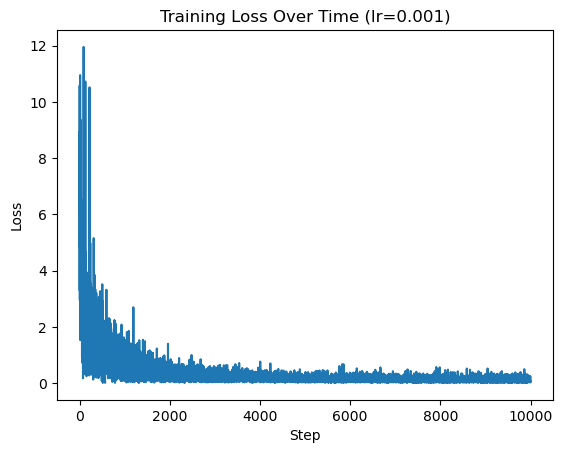

In [36]:
# Plot the loss curve and save (optional)
import matplotlib.pyplot as plt
import os

plt.plot(loss_vec)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time (lr=" + str(lr) + ")")
# Make sure the folder exists
if store_image:
    folder = f'figures/m_{m}_n_{n}_s_{seed}'
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/loss.pdf") 
plt.show()

# plot test accuracy

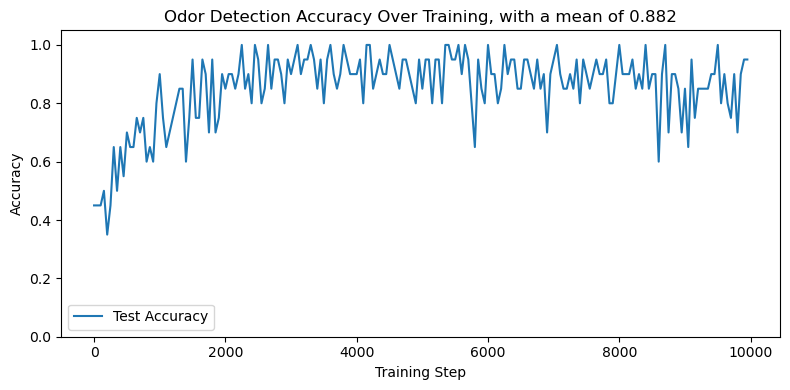

In [37]:
# Plot the test accuracy curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(torch.arange(0, steps, 50), accuracy_vec, label='Test Accuracy')
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title(f"Odor Detection Accuracy Over Training, with a mean of {mean_accuracy:.3f}")
plt.ylim(0, 1.05)
# plt.grid(True)
plt.legend()
plt.tight_layout()
if store_image:
    plt.savefig(f"{folder}/accuracy.pdf")

plt.show()

# plot the weight matrices

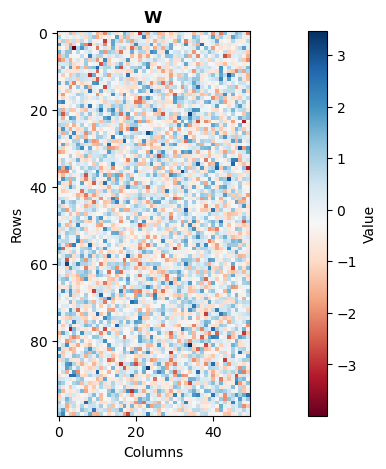

In [38]:
import torch
import matplotlib.pyplot as plt
W = enose_network.W.cpu().numpy()
# Plot using imshow
plt.figure(figsize=(15, 5))
plt.imshow(W, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W.pdf", bbox_inches='tight')
plt.show()

## plot the matrices

In [39]:
enose_network.fc1.bias

Parameter containing:
tensor([-0.3647], device='mps:0', requires_grad=True)

1
0.014486773


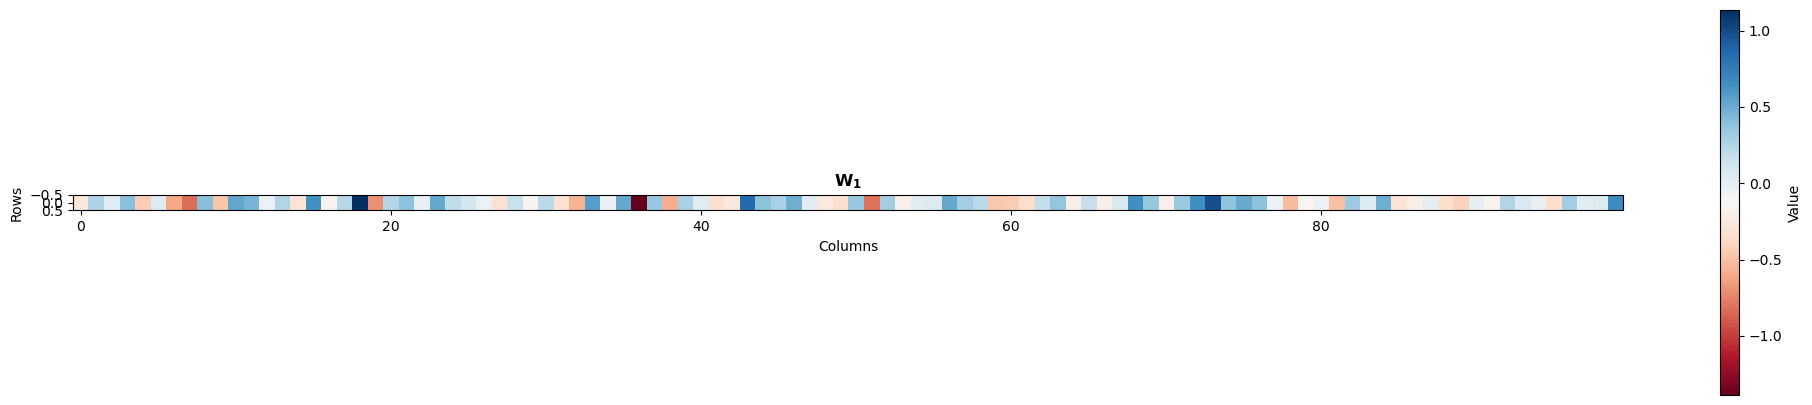

In [40]:
import torch
import matplotlib.pyplot as plt

W1 = enose_network.fc1.weight.detach().cpu().numpy()
b1 = enose_network.fc1.bias.detach().cpu().numpy()
print(b1.size)

W_h = W1 @ W
x1_hat_dagger = -b1[0]/W_h[0,0].item()
print(x1_hat_dagger)

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W1, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W1.pdf", bbox_inches='tight')
plt.show()

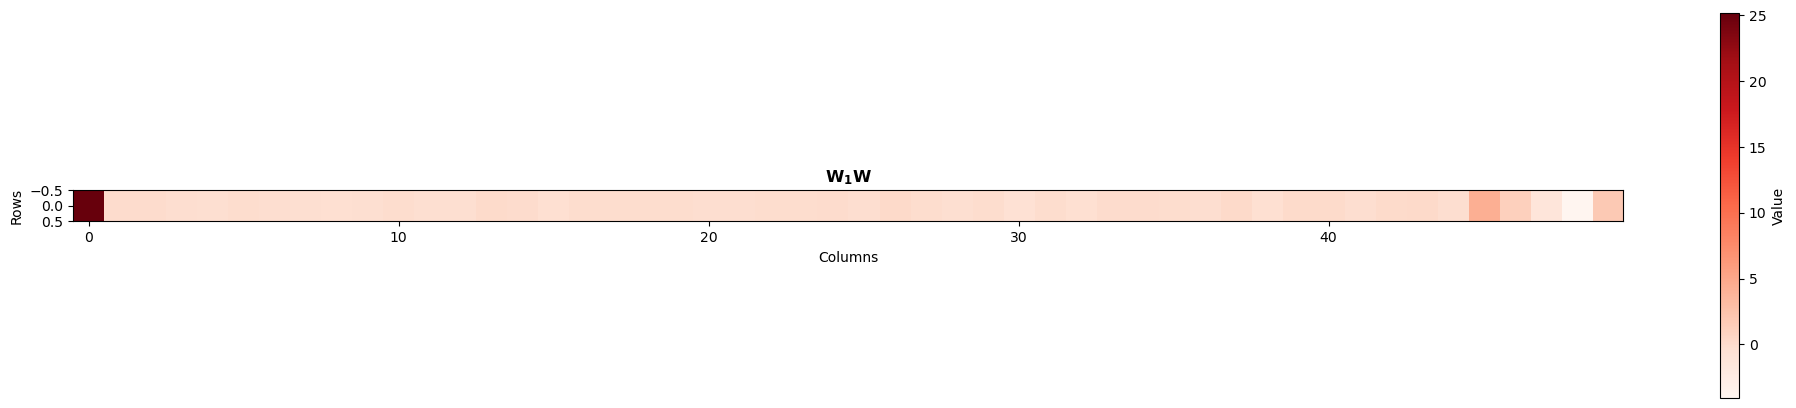

[ 2.51715221e+01  3.21136862e-02 -2.93099228e-02 -2.62406439e-01
 -4.11879689e-01 -1.88297138e-01 -2.41307646e-01 -3.30143660e-01
 -5.06481767e-01 -3.17761511e-01 -1.56056255e-01 -3.97603959e-01
 -3.65927994e-01  4.27354164e-02 -1.14213917e-02 -5.07975996e-01
 -1.66984543e-01 -1.00600295e-01 -9.84743685e-02 -1.28957763e-01
 -3.05738956e-01 -2.76410311e-01 -1.59980416e-01 -8.70572329e-02
  9.52665601e-03 -2.75548100e-01  1.91254944e-01 -1.64170116e-01
 -3.17294151e-01 -1.27753779e-01 -6.64618373e-01 -1.64765298e-01
 -4.55221146e-01 -9.65477806e-03 -4.08776030e-02 -1.77741155e-01
 -2.93814927e-01  2.05487728e-01 -4.62865263e-01  5.05215898e-02
  1.27547398e-01 -2.39833891e-01  6.15466163e-02  2.29953542e-01
 -2.85971254e-01  4.32937717e+00  1.14723516e+00 -1.43658864e+00
 -4.07603216e+00  1.76481676e+00]


In [41]:
import torch
import matplotlib.pyplot as plt

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W_h , cmap='Reds', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1 W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W_h.pdf")
# plt.savefig("figures/W_h.pdf")
plt.show()
plt.close()

# to verify that the first element dominates
print(W_h[0]) 

# plot the simplified 1-D curve, since the first element dominates

In [42]:
x_hat = threshold
print(x_hat)
print(x1_hat_dagger)

0.1
0.014486773


/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_14714/3394132130.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = torch.sigmoid( W_h[0][0]*x + b1 )


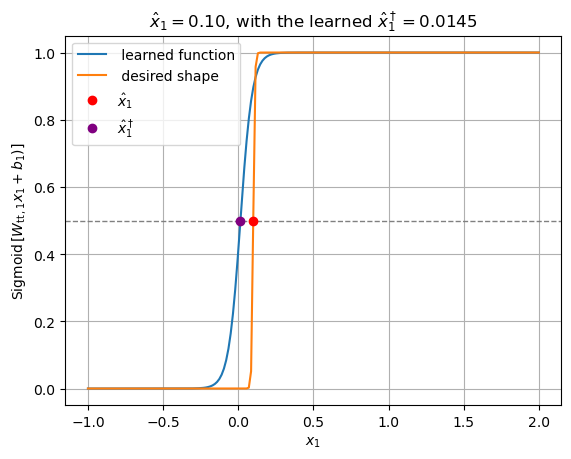

In [43]:
# x = torch.linspace(0, 1, 200)
x = torch.linspace(-1, 2, 200)

y = torch.sigmoid( W_h[0][0]*x + b1 )
y_2 = torch.sigmoid( 200*(x - x_hat) )
plt.plot(x, y, label =' learned function')
plt.plot(x, y_2, label = ' desired shape')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.plot(x_hat, 0.5, 'o', color='red', label=r'$\hat{x}_1$')
plt.plot(x1_hat_dagger, 0.5, 'o', color='purple', label=r'$\hat{x}_1^\dagger$')


plt.title(fr'$\hat{{x}}_1 = {x_hat:.2f} $, with the learned $\hat{{x}}_1^\dagger = {x1_hat_dagger:.4f} $')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\operatorname{Sigmoid}\left[ W_{\operatorname{tt},1} x_1 + b_1 ) \right]$')
plt.legend()
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/pickup_first_dim.pdf", bbox_inches='tight')
plt.show()

# perturbation of W matrix*

In [25]:
scalars = np.arange(0.1,10.1,0.1).tolist()
corr_scalars = np.arange(0.01, 1.01, 0.01).tolist()
poscorr_perturb_accuracies = torch.zeros(len(scalars))
randn_perturb_accuracies = torch.zeros(len(scalars))
scalarmult_perturb_accuracies = torch.zeros(len(scalars))
uncorr_perturb_accuracies = torch.zeros(len(scalars))
original_W = enose_network.W.clone() # original odorant-to-measurement matrix W


# iterate the same number of times but for random re-initializations
for idx,scalar in enumerate(scalars):

    # change W matrix in the positive direction
    enose_network.W = torch.randn(enose_network.W.shape[0], enose_network.W.shape[1]).to(device)

    # evaluate test accuracy of NN
    randn_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, nonzero_test_conc, nonzero_test_labelsss, num_data, num_training, test_batch_size, device)


# iterate over magnitude of scalar multiplication 
for idx,scalar in enumerate(scalars):

    # change W matrix
    enose_network.W = (original_W * scalar).to(device)

    # evaluate test accuracy of NN
    scalarmult_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, test_conc, test_labels, num_data, num_training, test_batch_size, device)


# iterate over magnitude of positively-correlated noise 
for idx,percent in enumerate(corr_scalars):

    # change W matrix in the positive direction
    enose_network.W = (torch.abs(original_W) * percent + original_W).to(device)

    # evaluate test accuracy of NN
    poscorr_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, test_conc, test_labels, num_data, num_training, test_batch_size, device)

# iterate over magnitude of positively-uncorrelated noise 
for idx,percent in enumerate(corr_scalars):

    # change W matrix in either positive or negative direction
    random_int_tensor = (2 * torch.randint(0,2,(original_W.shape[0], original_W.shape[1])) - 1).to(device)
    enose_network.W = (torch.abs(original_W) * random_int_tensor * percent + original_W).to(device)
    # (1 + alpha) or (1 - alpha)

    # evaluate test accuracy of NN
    poscorr_perturb_accuracies[idx] = network.eval_model_accuracy(enose_network, test_conc, test_labels, num_data, num_training, test_batch_size, device)

scalarmult_mean_accuracy = torch.mean(scalarmult_perturb_accuracies)
poscorr_mean_accuracy = torch.mean(poscorr_perturb_accuracies)
pos_uncorr_mean_accuracy = torch.mean(uncorr_perturb_accuracies)
randn_mean_accuracy = torch.mean(randn_perturb_accuracies)



# plots to view
for change_type in range(0,1):
    plt.figure(figsize=(8, 4))
    change_type_str = "scalarmult"
    plot_mean_accuracy = 0
    plot_accuracy_vec = scalarmult_perturb_accuracies
    plot_scalars = scalars
    plot_mean_accuracy = scalarmult_mean_accuracy

    # if change_type == 0:
    #     change_type_str = "randn"
    #     plot_mean_accuracy = randn_mean_accuracy
    #     plot_accuracy_vec = randn_perturb_accuracies
    # elif change_type == 1:
    #     change_type_str = "scalarmult"
    #     plot_mean_accuracy = scalarmult_mean_accuracy
    #     plot_accuracy_vec = scalarmult_perturb_accuracies
    # elif change_type == 2:
    #     change_type_str = "poscorr"
    #     plot_mean_accuracy = poscorr_mean_accuracy
    #     plot_accuracy_vec = poscorr_perturb_accuracies
    #     plot_scalars = corr_scalars

    plt.plot(plot_scalars, plot_accuracy_vec, label='Test Accuracy after ' + change_type_str + ' W Change')
    plt.xlabel("Scalar Value")
    plt.ylabel("Accuracy")
    plt.title(f"Odor Detection Accuracy Over Training, with a mean of {plot_mean_accuracy:.3f}")
    plt.ylim(0, 1.05)
    # plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if store_image:
        fig_folder = '/Users/ericxu/Documents/Github/Murthy_NeuralNetwork/2_sorted_out_variant_one_layer/eric_weight_perturb_figures' 
        plt.savefig(f"{fig_folder}/" + change_type_str + "_perturb_accuracy.pdf")
    plt.show()



NameError: name 'nonzero_test_labelsss' is not defined